In [1]:
%load_ext autoreload
%autoreload 2

import os
import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import *
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io
from scripts.pseudo_decoding.belief_partitions.choice_pref_vector_alignment import (
    OUTPUT_PATH, WHOLE_POP, get_mode,
)

plt.rcParams.update({"font.size": 16})

# Choice / preference population-vector alignment

Per feature and time bin, two mean-difference vectors are built over z-scored activity, with
per-unit coordinates concatenated across sessions:

```
v_choice = mean(r | Chose X)  - mean(r | Not Chose X)
v_pref   = mean(r | High X)   - mean(r | High Not X)
```

and the plot shows `cos(v_choice, v_pref)` against its session-permute shuffle. This is the
*encoding* counterpart to the choice-axis projection in
`20260810_visualize_pref_on_choice_axis.ipynb`, which asks the *readout* question with decoder
weights. `claude_notes/weight_vs_mean_difference_axes.md` works out why the two are different
quantities rather than two estimators of the same one.

Computed by `scripts/pseudo_decoding/belief_partitions/choice_pref_vector_alignment.py`. `v_pref`
is always built from `Response Correct` / `Choice Chose` trials; which trials `v_choice` is built
from is set by `CHOICE_BEH_FILTERS` below, matching that script's `--choice_beh_filters`: `{}` for
all valid trials, `{"Response": "Correct"}` for the correct-only vector matched to `v_pref`'s own
pool. Each is stored under its own mode, so the two sit side by side. Error bands are SE across the
12 features.

**One run covers every population.** Each unit's coordinate is computed independently of every
other unit's, so a region is a subset of the same per-unit vectors rather than a separate fit --
`region` is a column in the results, not a separate run directory. Units outside the 6 regions of
interest still count toward `whole_pop`, so the regions do not sum to the whole population.

## How to read the magnitude -- important

**`cos_sim` is not deattenuated, so its value is not a percentage of alignment.** Finite-trial
noise inflates both norms in the denominator, and by a factor that varies across time bins
(measured at 0.07-0.26 on CIRCLE/SA/StimOnset). So:

- read it **only** as a contrast against its own shuffle,
- do **not** read `cos_sim = 0.13` as "13% aligned" -- the true value is several-fold larger,
- do **not** compare one time bin, one feature, **or one region** against another as if
  differences in `cos_sim` were differences in alignment,
- do **not** compare the all-trials and correct-only `v_choice` runs against each other either:
  the correct-only vector is built from fewer trials, so it is attenuated more, and a lower
  `cos_sim` there is not weaker alignment. Each run has its own shuffle; the gap over that shuffle
  is what carries across.

That third point bites hardest for regions: a region contributes 15-141 units per feature against
382-681 for the whole population, and fewer units means more attenuation. So MPal reading higher
than ITC is **not** evidence of stronger alignment in MPal. A regional dissociation claim needs
unit-count-matched subsampling first (`choice_pref_axis_geometry.md` shared caveat 3), which the
saved per-unit `*_vectors.pickle` files support without re-running anything.
`claude_notes/cosine_similarity_debiasing.md` has the measured attenuation and the two recipes
(`cos_cv`, `cos_deatt`) that would lift the restriction.

The shuffle does **not** sit at zero. That is the choice-sequence autocorrelation x neural-drift
interaction already documented in `claude_notes/trial_subselection_autocorrelation_matching.md`
and `choice_pref_axis_geometry.md` caveat 1, and it is why the shuffle rather than 0 is the
reference. Significance bars are the one-sided permutation test of each population against **its
own** shuffle at each timepoint, thicker for smaller p (p < 0.05 / 0.01 / 0.001,
`visualization_utils.SIG_LEVELS`). Significance *is* comparable across regions; magnitude is not.

In [10]:
# which alignment run to read: the trials v_choice was built from, matching the compute script's
# --choice_beh_filters. {} is the all-trials vector, {"Response": "Correct"} the correct-only one,
# whose files sit beside it in the same run dir. The outputs stored in this notebook are {}.
CHOICE_BEH_FILTERS = {"Response": "Correct"}
# CHOICE_BEH_FILTERS = {}
RUN_MODE = get_mode(CHOICE_BEH_FILTERS)

SERIES_NAMES = {
    RUN_MODE: "alignment",
    f"{RUN_MODE}_shuffle": "alignment shuffle",
}
SERIES_ORDER = ["alignment", "alignment shuffle"]
SERIES_TO_COLOR = {"alignment": "tab:green", "alignment shuffle": "#98df8a"}
SIG_BAR_SERIES = ["alignment"]

TRIAL_EVENTS = ["StimOnset", "FeedbackOnsetLong"]
# whole population first, then the 6 regions of interest
POPULATIONS = [WHOLE_POP] + list(REGIONS_OF_INTEREST)


def get_args(trial_event):
    """
    Every population lives in one run dir, so region is not part of the naming. No filters in the
    dir name either: each contrast carries its own filters inside the compute script, and they
    can't both be encoded in one run name -- the choice contrast's ride in the mode instead, which
    is what picks one of the two runs apart inside a shared dir.
    """
    args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
    args.subject = "both"
    args.mode = RUN_MODE
    args.trial_event = trial_event
    args.base_output_path = OUTPUT_PATH
    args.region_level = None
    args.regions = None
    args.sig_unit_level = None
    args.beh_filters = {}
    return args


def read_alignment(trial_event, region=None):
    """
    True run plus shuffles, one row per (region, feat, TimeIdx) per run
    """
    res = belief_partitions_io.read_alignment(get_args(trial_event))
    if region is not None:
        res = res[res.region == region]
    res["series"] = res["mode"].map(SERIES_NAMES)
    res["trial_event"] = trial_event
    return res


def read_pvals(trial_event, region):
    """
    Per-timepoint p value of one population against its own shuffle, written by
    p_val_computations/compute_p_vals_for_choice_pref_align.py -- run with the same
    --choice_beh_filters as CHOICE_BEH_FILTERS here
    """
    dir = belief_partitions_io.get_dir_name(get_args(trial_event), make_dir=False)
    p_vals = pd.read_pickle(os.path.join(dir, f"{RUN_MODE}_pvals.pickle"))
    return p_vals[p_vals.region == region]

In [11]:
def plot_alignment(region, title=None):
    """
    Both trial events side by side, in the style of visualization_utils.plot_combined_accs
    """
    stim_res = read_alignment("StimOnset", region)
    fb_res = read_alignment("FeedbackOnsetLong", region)

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 3.5), sharey="row",
        width_ratios=[stim_res.Time.nunique(), fb_res.Time.nunique()]
    )
    for ax, res in ((ax1, stim_res), (ax2, fb_res)):
        sns.lineplot(
            res, x="Time", y="cos_sim", hue="series", hue_order=SERIES_ORDER,
            palette=SERIES_TO_COLOR, linewidth=3, ax=ax, errorbar="se"
        )
        # 0 is the no-alignment reference, but NOT the null -- the shuffle is
        ax.axhline(y=0, linestyle="dotted", color="black")
        ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)

    # significance vs. this population's own shuffle, below the traces. Read the shared limits
    # before any bar has a chance to rescale the axes.
    bottom, top = ax1.get_ylim()
    spacing = 0.08 * (top - bottom)
    for ax, trial_event in ((ax1, "StimOnset"), (ax2, "FeedbackOnsetLong")):
        p_vals = read_pvals(trial_event, region)
        for i, series in enumerate(SIG_BAR_SERIES):
            visualization_utils.plot_sig_bars(
                p_vals, bottom - (i + 1) * spacing, ax, color=SERIES_TO_COLOR[series]
            )
    # shared y, so these set both: make room for the bars without rescaling the traces, and keep
    # the ticks on the traces, since a cos_sim tick inside the bar strip reads as data
    ax1.set_ylim(bottom - (len(SIG_BAR_SERIES) + 0.5) * spacing, top)
    ax1.set_yticks([tick for tick in ax1.get_yticks() if bottom <= tick <= top])

    ax1.axvline(-.5, color="grey", linestyle="dotted", linewidth=3)
    ax1.set_xlabel("Time to stimuli appear (s)")
    stim_ticks = [-1, -.5, 0, .5, 1]
    ax1.set_xticks(stim_ticks)
    ax1.set_xticklabels(stim_ticks)
    ax1.set_ylabel("cos(v_choice, v_pref)")

    ax2.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
    ax2.set_xlabel("Time to feedback (s)")
    fb_ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
    ax2.set_xticks(fb_ticks)
    ax2.set_xticklabels(fb_ticks)

    visualization_utils.format_plot([ax1, ax2])
    ax1.get_legend().remove()
    ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig, (ax1, ax2), pd.concat((stim_res, fb_res))

## Whole population

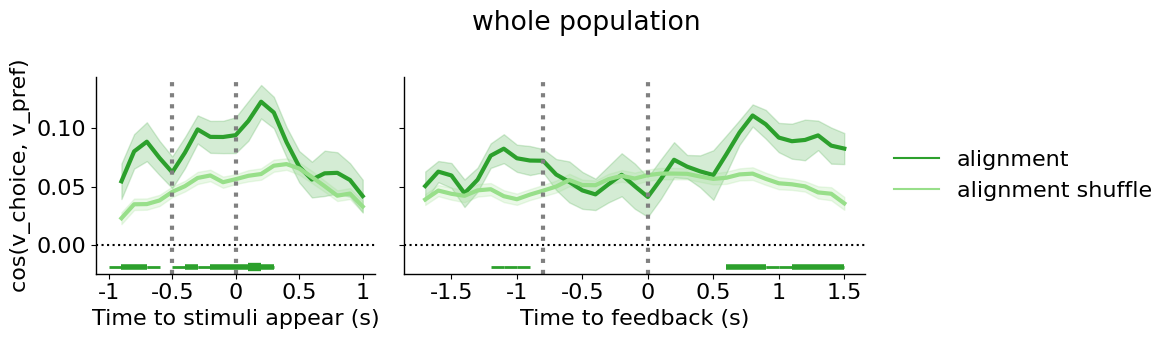

In [12]:
fig, _, whole_pop_res = plot_alignment(WHOLE_POP, title="whole population")

## Regions of interest

Each region against its own shuffle. Recall the y axes are not comparable between regions -- see
the note at the top.

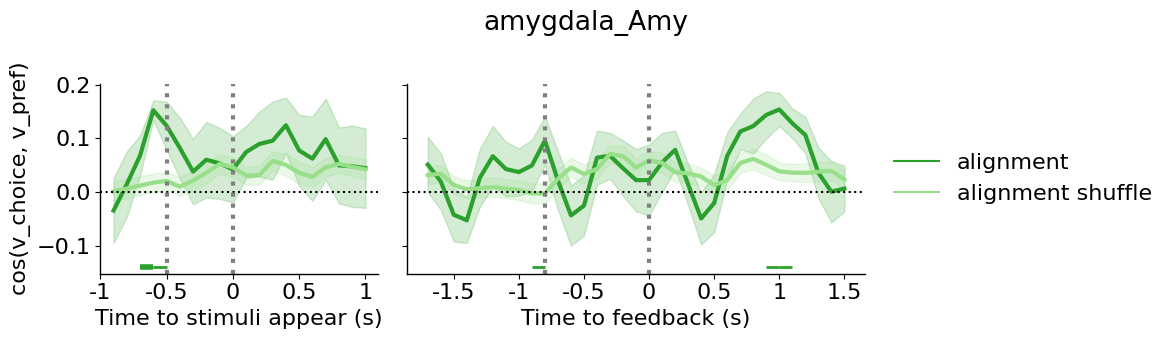

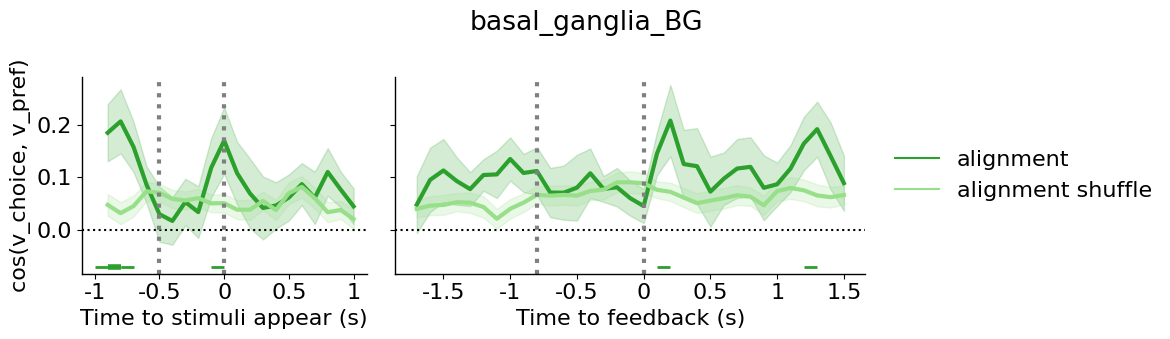

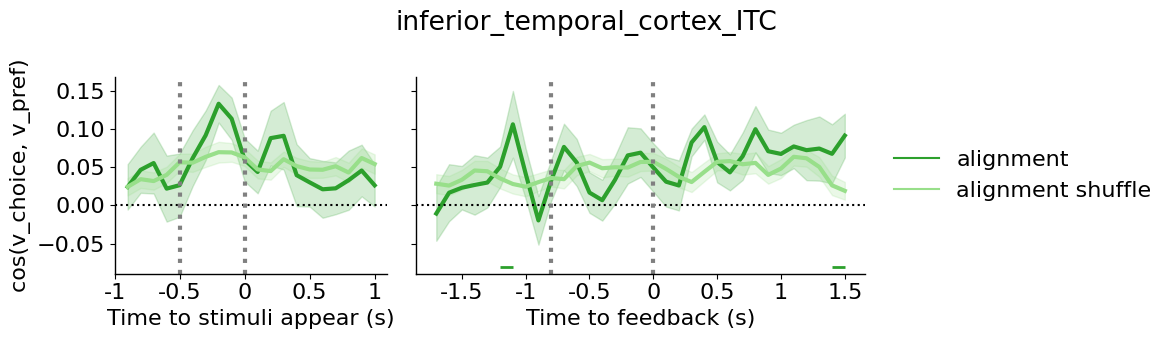

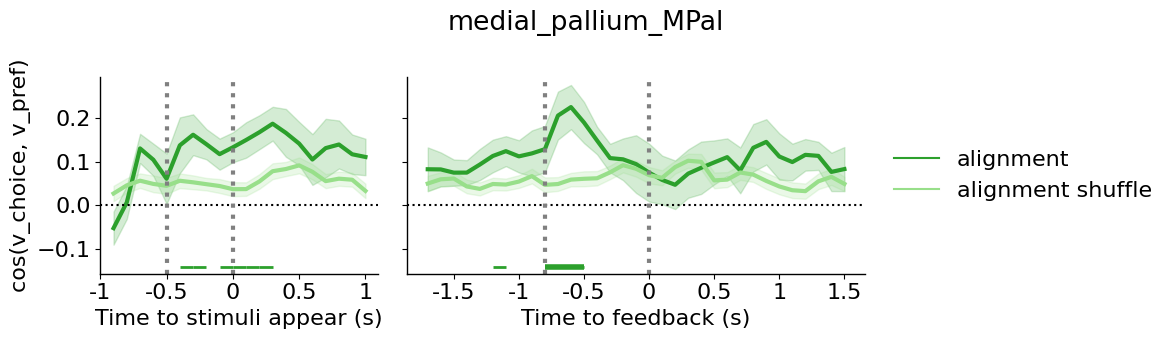

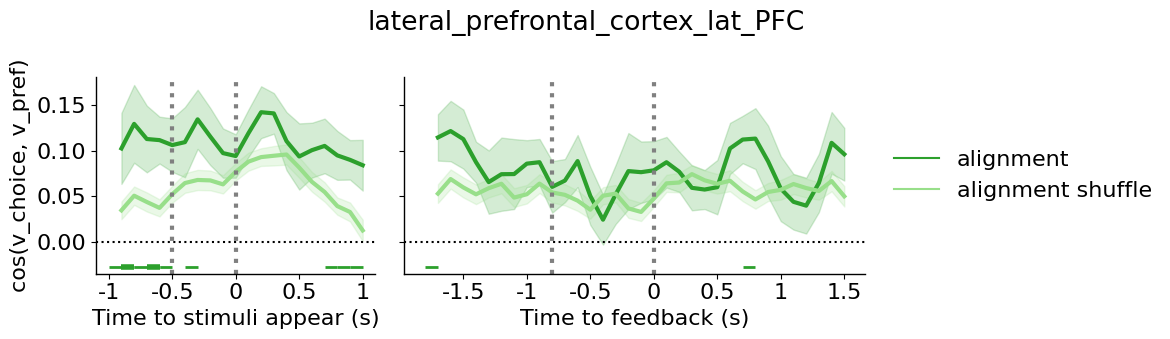

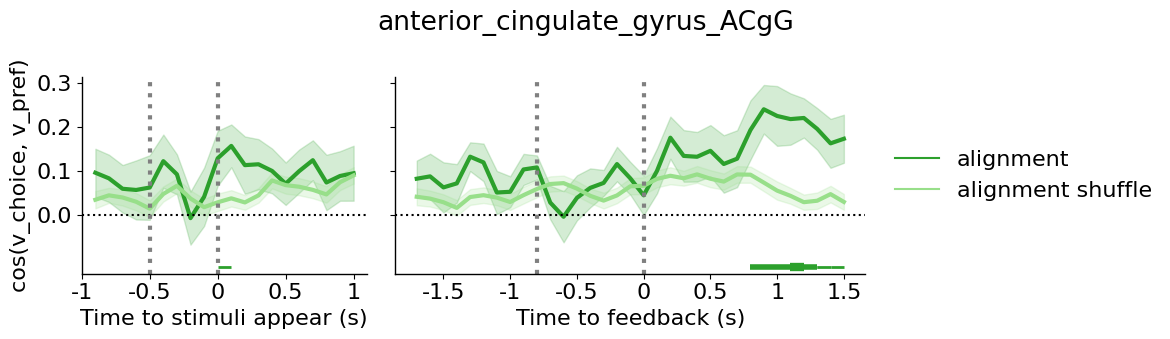

In [13]:
all_res = [whole_pop_res]
for region in POPULATIONS[1:]:
    _, _, res = plot_alignment(region, title=region)
    all_res.append(res)
all_res = pd.concat(all_res)

## Significant timepoints per region

Timepoints where the alignment sits above its own shuffle, one row per population.

In [14]:
sig = []
for trial_event in TRIAL_EVENTS:
    for region in POPULATIONS:
        p = read_pvals(trial_event, region)
        hits = p[p.p < 0.05].Time.to_numpy()
        sig.append({
            "trial_event": trial_event, "region": region,
            "n_sig_bins": len(hits), "n_bins": len(p), "min_p": p.p.min(),
            "sig_window": f"{hits.min():+.1f} to {hits.max():+.1f}" if len(hits) else "-",
            "sig_times": np.round(hits, 1),
        })
sig = pd.DataFrame(sig).set_index(["trial_event", "region"])
sig[["n_sig_bins", "n_bins", "min_p", "sig_window"]]

n_sig_bins  n_bins  \
trial_event       region                                                  
StimOnset         whole_pop                                  12      20   
                  amygdala_Amy                                2      20   
                  basal_ganglia_BG                            4      20   
                  inferior_temporal_cortex_ITC                0      20   
                  medial_pallium_MPal                         6      20   
                  lateral_prefrontal_cortex_lat_PFC           9      20   
                  anterior_cingulate_gyrus_ACgG               1      20   
FeedbackOnsetLong whole_pop                                  12      33   
                  amygdala_Amy                                3      33   
                  basal_ganglia_BG                            2      33   
                  inferior_temporal_cortex_ITC                2      33   
                  medial_pallium_MPal                         4      33   
                  lateral_prefrontal_cortex_lat_PFC           2      33   
                  anterior_cingulate_gyrus_ACgG               7      33   

                                                     min_p    sig_window  
trial_event       region                                                  
StimOnset         whole_pop                          0.000  -0.9 to +0.3  
                  amygdala_Amy                       0.004  -0.6 to -0.5  
                  basal_ganglia_BG                   0.005  -0.9 to +0.0  
                  inferior_temporal_cortex_ITC       0.078             -  
                  medial_pallium_MPal                0.012  -0.3 to +0.3  
                  lateral_prefrontal_cortex_lat_PFC  0.008  -0.9 to +1.0  
                  anterior_cingulate_gyrus_ACgG      0.016  +0.1 to +0.1  
FeedbackOnsetLong whole_pop                          0.001  -1.1 to +1.5  
                  amygdala_Amy                       0.014  -0.8 to +1.1  
                  basal_ganglia_BG                   0.012  +0.2 to +1.3  
                  inferior_temporal_cortex_ITC       0.023  -1.1 to +1.5  
                  medial_pallium_MPal                0.001  -1.1 to -0.5  
                  lateral_prefrontal_cortex_lat_PFC  0.030  -1.7 to +0.8  
                  anterior_cingulate_gyrus_ACgG      0.000  +0.9 to +1.5

In [15]:
# the individual significant timepoints, if the windows above are not contiguous
for (trial_event, region), row in sig.iterrows():
    print(f"{trial_event:18s} {region:34s} {row.sig_times}")

StimOnset          whole_pop                          [-0.9 -0.8 -0.7 -0.6 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3]
StimOnset          amygdala_Amy                       [-0.6 -0.5]
StimOnset          basal_ganglia_BG                   [-0.9 -0.8 -0.7  0. ]
StimOnset          inferior_temporal_cortex_ITC       []
StimOnset          medial_pallium_MPal                [-0.3 -0.2  0.   0.1  0.2  0.3]
StimOnset          lateral_prefrontal_cortex_lat_PFC  [-0.9 -0.8 -0.7 -0.6 -0.5 -0.3  0.8  0.9  1. ]
StimOnset          anterior_cingulate_gyrus_ACgG      [0.1]
FeedbackOnsetLong  whole_pop                          [-1.1 -1.  -0.9  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4  1.5]
FeedbackOnsetLong  amygdala_Amy                       [-0.8  1.   1.1]
FeedbackOnsetLong  basal_ganglia_BG                   [0.2 1.3]
FeedbackOnsetLong  inferior_temporal_cortex_ITC       [-1.1  1.5]
FeedbackOnsetLong  medial_pallium_MPal                [-1.1 -0.7 -0.6 -0.5]
FeedbackOnsetLong  lateral_prefrontal_cortex_

## Summary

Mean `cos_sim` over all time bins, features and runs, and the gap over the shuffle. The **gap** is
the interpretable quantity within a population; absolute levels are attenuated by an unknown factor
that differs between populations, so the `gap` column is not a cross-region ranking either.

In [ ]:
summary = all_res.groupby(["trial_event", "region", "series"]).cos_sim.mean().unstack("series")
summary["gap"] = summary["alignment"] - summary["alignment shuffle"]
units = all_res[all_res["mode"] == RUN_MODE].groupby(["trial_event", "region"]).n_units.agg(["min", "max"])
summary = summary.join(units.rename(columns={"min": "units_min", "max": "units_max"}))
summary = summary.reindex(TRIAL_EVENTS, level="trial_event").reindex(POPULATIONS, level="region")
summary.round(4)